# Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install missingno
import missingno as msno
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load Data

In [2]:
# load the csv file

df1 = pd.read_csv("swiggy.csv")

df1.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
df = df1.copy()

In [4]:
df.shape

(45593, 20)

In [5]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [6]:
# shape of data

rows, cols = df.shape

print("The dataset has {} rows and {} columns".format(rows,cols))
print(f"The dataset has {rows} rows and {cols} columns")

The dataset has 45593 rows and 20 columns
The dataset has 45593 rows and 20 columns


In [7]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

**Corrections**:

1. Age column should be numerical.
2. Ratings should be float.
3. Date and time columns should be date and time.
4. Vehicle conditions seems to be categorical column which is integer encoded.
5. Multiple deliveries should be integer column.
6. Target column should also be numbers.

In [8]:
# missing values in data

df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [9]:
df.isnull().sum().sum()

np.int64(0)

**There are no missing values in the data**

In [10]:
# sample 50 rows of data for viewing

df.sample(15)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
8766,0x30da,HYDRES03DEL02,22,4.8,17.422819,78.449578,17.552819,78.579578,02-04-2022,23:35:00,23:40:00,conditions Fog,Low,2,Buffet,electric_scooter,0,No,Metropolitian,(min) 27
16457,0x76c0,BANGRES09DEL03,31,4.6,12.934179,77.615797,12.994179,77.675797,13-03-2022,20:25:00,20:30:00,conditions Cloudy,Jam,2,Drinks,scooter,1,No,Urban,(min) 27
13857,0xab2b,BANGRES02DEL02,35,4.8,12.970221,77.645396,13.020221,77.695396,11-03-2022,21:20:00,21:25:00,conditions Sunny,Jam,1,Snack,motorcycle,1,No,Metropolitian,(min) 20
42014,0x522e,HYDRES04DEL02,34,4,17.411028,78.329645,17.461028,78.379645,15-03-2022,19:50:00,20:00:00,conditions Sandstorms,Jam,2,Snack,scooter,0,No,Urban,(min) 33
209,0x41ea,MYSRES08DEL01,24,4.7,12.297954,76.665169,12.337954,76.705169,19-03-2022,15:30:00,15:40:00,conditions Fog,Medium,1,Buffet,scooter,NaN,No,Metropolitian,(min) 13
38427,0x19a9,RANCHIRES17DEL02,36,4.9,23.374878,85.335739,23.424878,85.385739,28-03-2022,21:45:00,22:00:00,conditions Stormy,Jam,1,Meal,motorcycle,1,No,Metropolitian,(min) 26
15191,0x2631,JAPRES01DEL03,38,4.5,26.905190,75.810753,26.935190,75.840753,24-03-2022,22:35:00,22:40:00,conditions Windy,Low,2,Drinks,scooter,0,No,Metropolitian,(min) 21
7892,0xa4e0,VADRES18DEL01,22,4.9,0.000000,0.000000,0.010000,0.010000,01-03-2022,11:15:00,11:25:00,conditions Sunny,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 10
19687,0x2eb8,CHENRES11DEL02,33,4.6,13.064181,80.236442,13.144181,80.316442,29-03-2022,18:25:00,18:35:00,conditions Stormy,Medium,1,Buffet,motorcycle,0,No,Metropolitian,(min) 22
32572,0x8991,INDORES07DEL02,39,4,22.722634,75.886959,22.802634,75.966959,08-03-2022,19:20:00,19:30:00,conditions Fog,Jam,1,Snack,scooter,2,No,Metropolitian,(min) 40


**NaN values in the data**

Investigate further

# Missing values

Missing values are string type in the data with an extra space.

In [11]:
df.loc[43317,"Delivery_person_Ratings"]

'NaN '

In [12]:
df['Delivery_person_Ratings'].value_counts().index.to_list()

['4.8',
 '4.7',
 '4.9',
 '4.6',
 '5',
 '4.5',
 'NaN ',
 '4.1',
 '4.2',
 '4.3',
 '4.4',
 '4',
 '3.5',
 '3.8',
 '3.7',
 '3.6',
 '3.9',
 '6',
 '1',
 '3.4',
 '3.1',
 '3.2',
 '3.3',
 '2.6',
 '2.7',
 '2.5',
 '2.8',
 '2.9',
 '3']

In [13]:
# String NaNs in the data

(df == "NaN ").sum().sum()

np.int64(8515)

8515 such NaN's in the data

In [14]:
# column wise string NaNs

(df == "NaN ").sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [15]:
# replace string NaN with NaN

df = df.replace("NaN ",np.nan)


In [16]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [17]:
# verify missing values in the data

df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

**Verified that string NaNs converted to Nan**

In [18]:
df["Weatherconditions"].value_counts().index.to_list()

['conditions Fog',
 'conditions Stormy',
 'conditions Cloudy',
 'conditions Sandstorms',
 'conditions Windy',
 'conditions Sunny',
 'conditions NaN']

In [19]:
# NaN in the weather column
df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ","").replace("NaN",np.nan)

In [20]:
df["Weatherconditions"].isnull().sum()


np.int64(616)

In [21]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


**616 missing values in the weather column**

In [22]:
# df with all the missing values replace

missing_df = (
df.replace("NaN ",np.nan).assign(Weatherconditions = lambda df_ : (df_['Weatherconditions'].str.replace("conditions ","")
                                                                   .replace("NaN",np.nan)))
)

missing_df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [23]:
# missing values in data

missing_df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [24]:
missing_df.shape

(45593, 20)

In [25]:
# total missing values in data

missing_df.isna().sum().sum()

np.int64(9131)

In [26]:
8515 + 616

9131

## Missing Value Analysis

### Matrix

<Axes: >

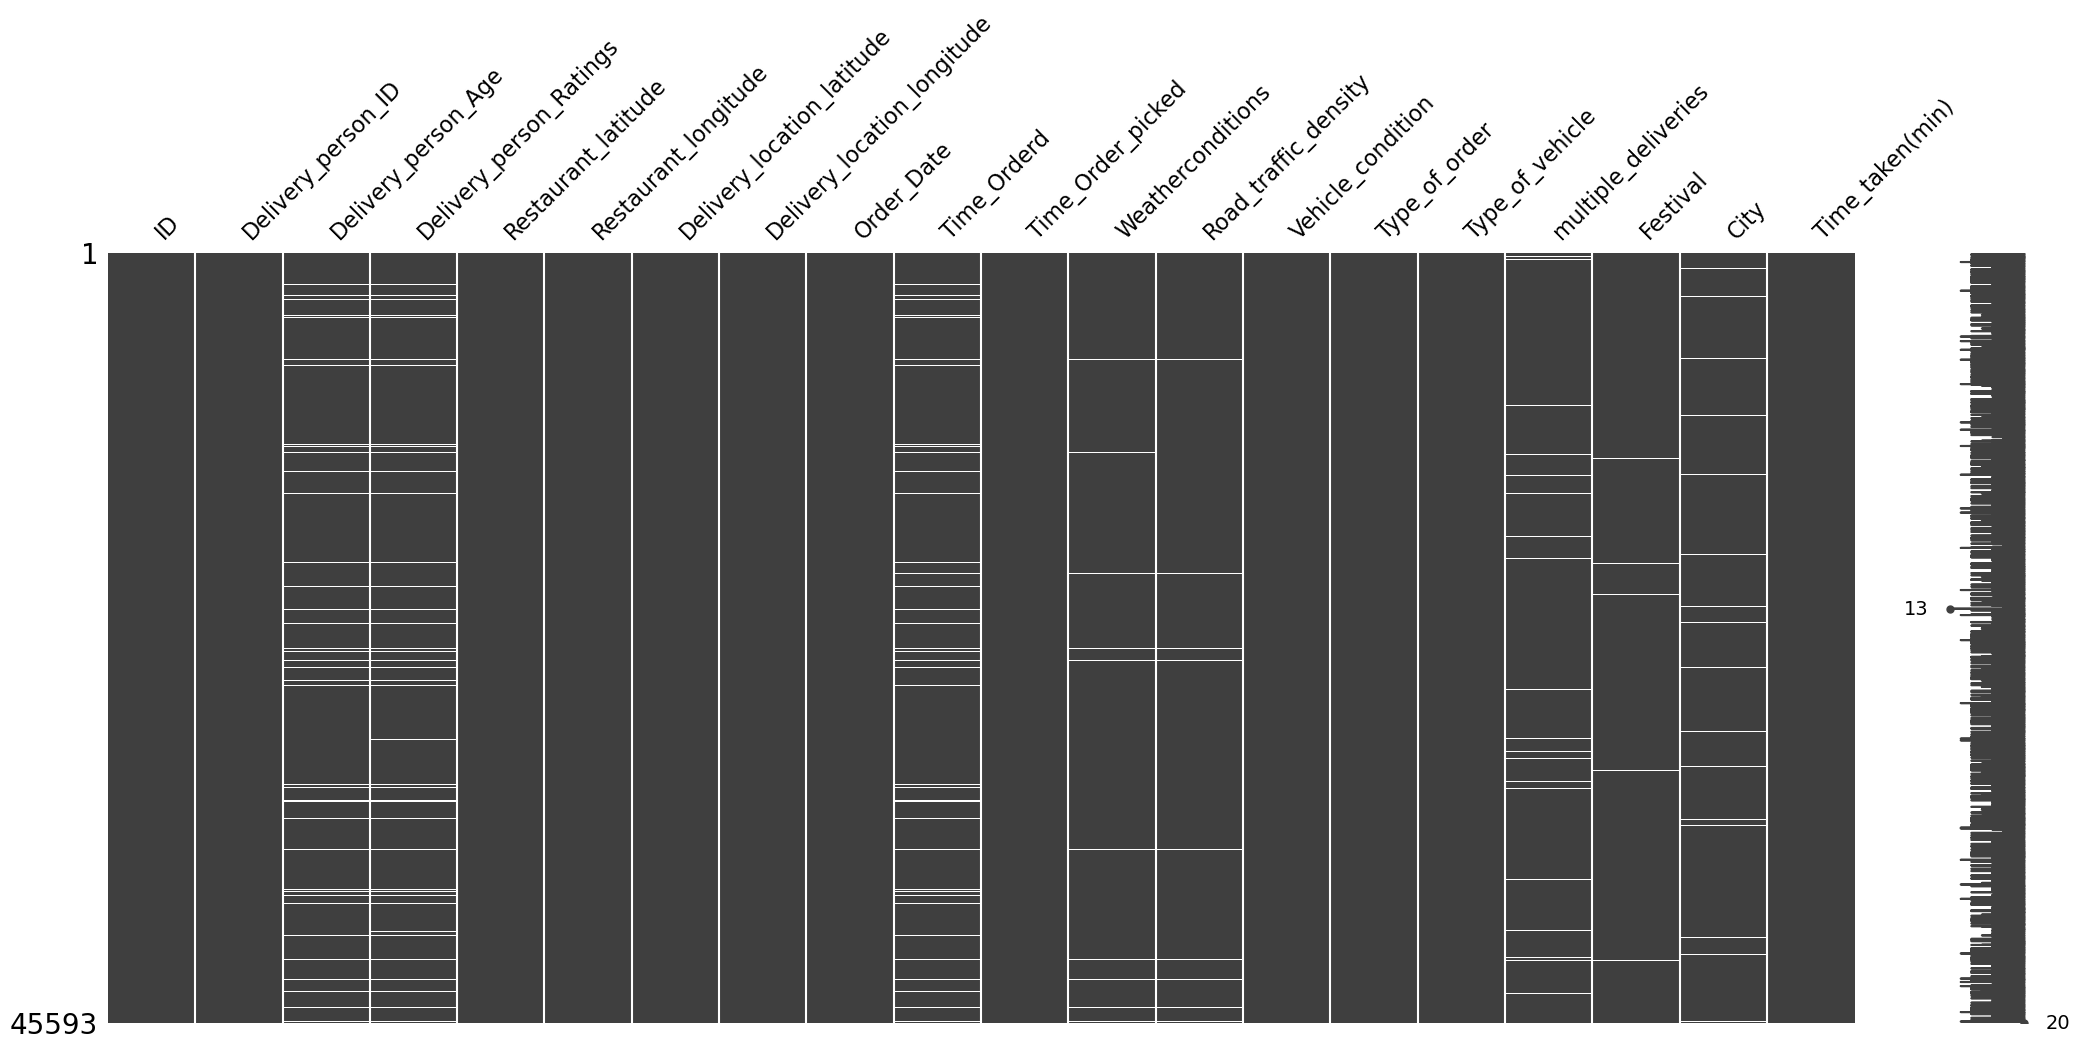

In [27]:
# missing values matrix
import missingno as msno

msno.matrix(df)

### Count of Missing Values

<Axes: >

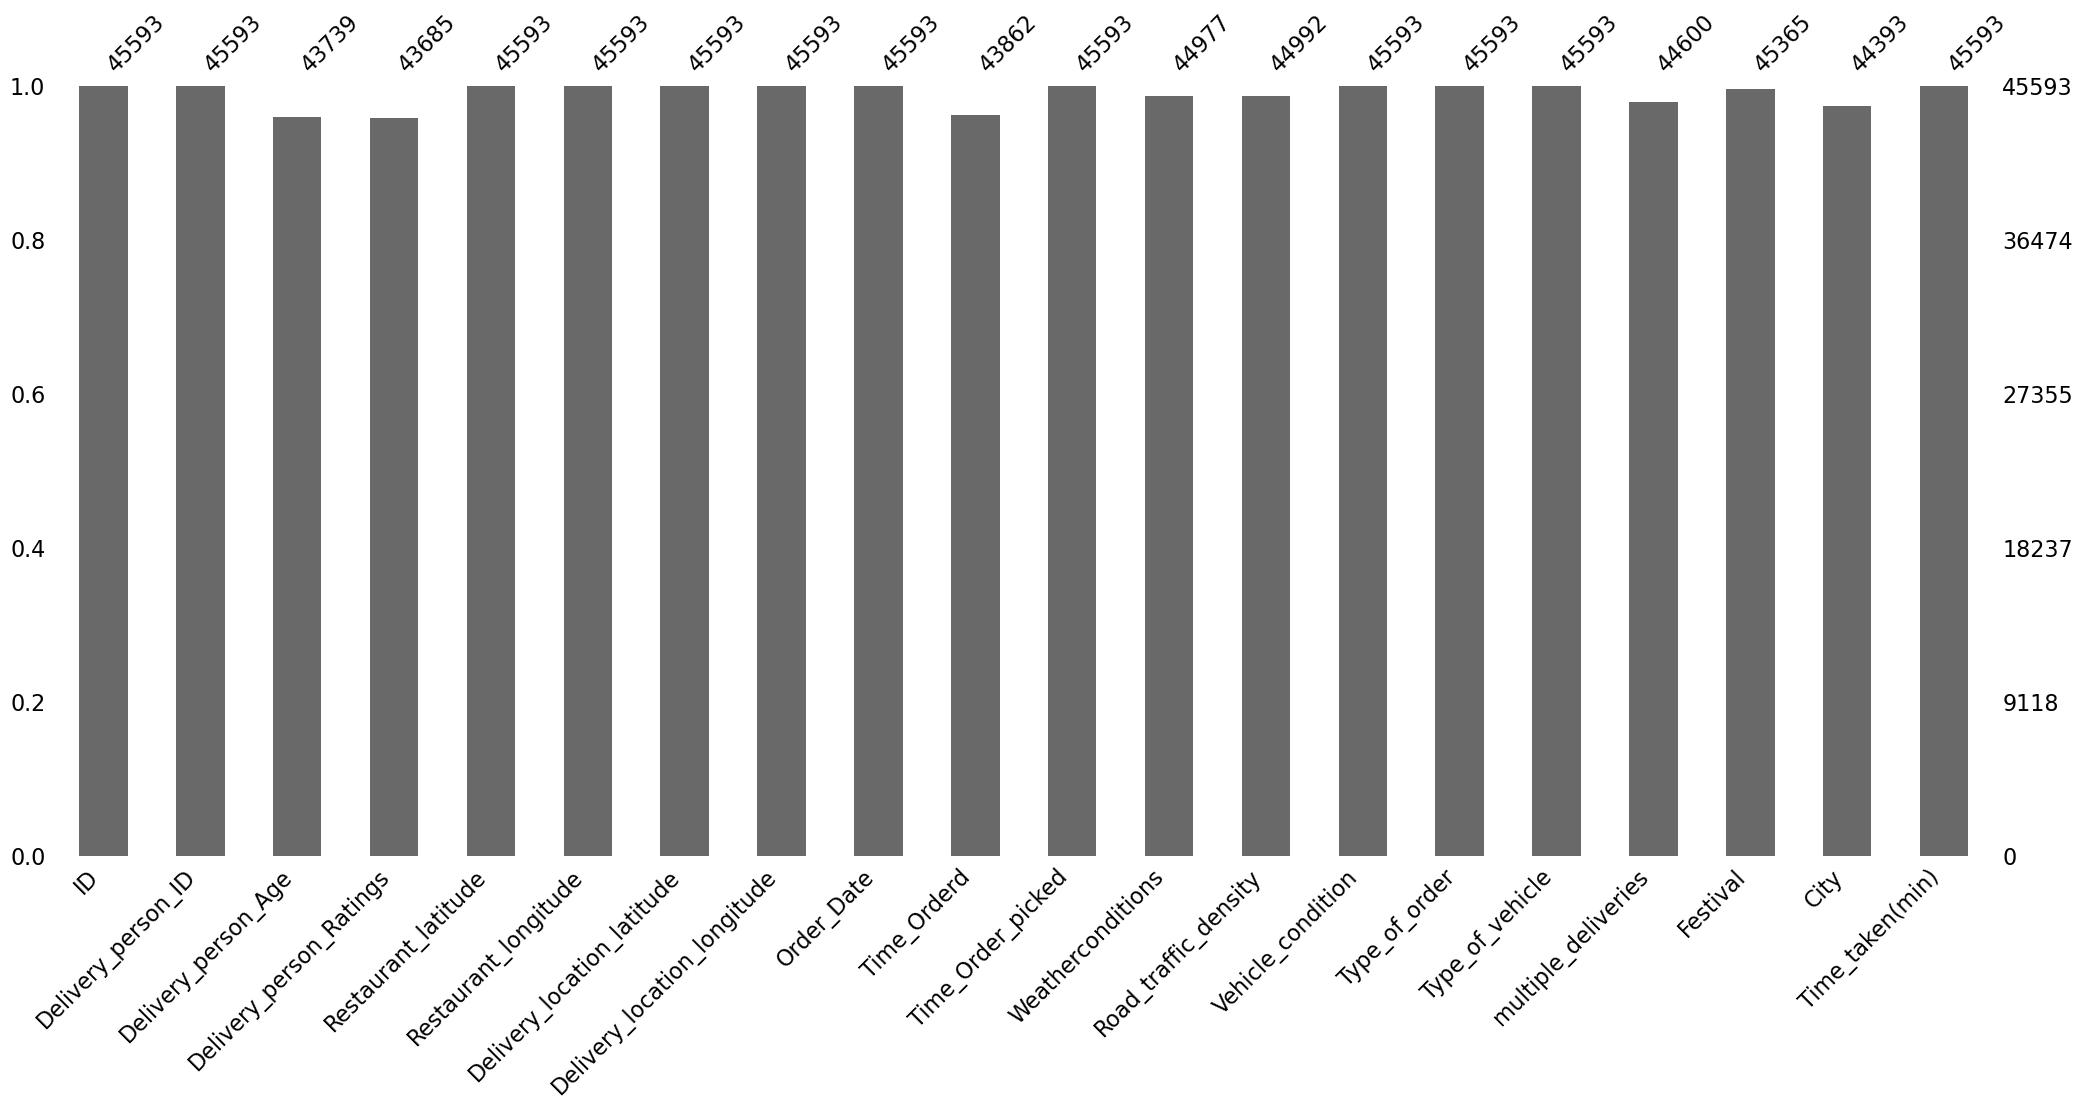

In [28]:
# bar plot for columns having missing data

msno.bar(df)

### Missing Corr

<Axes: >

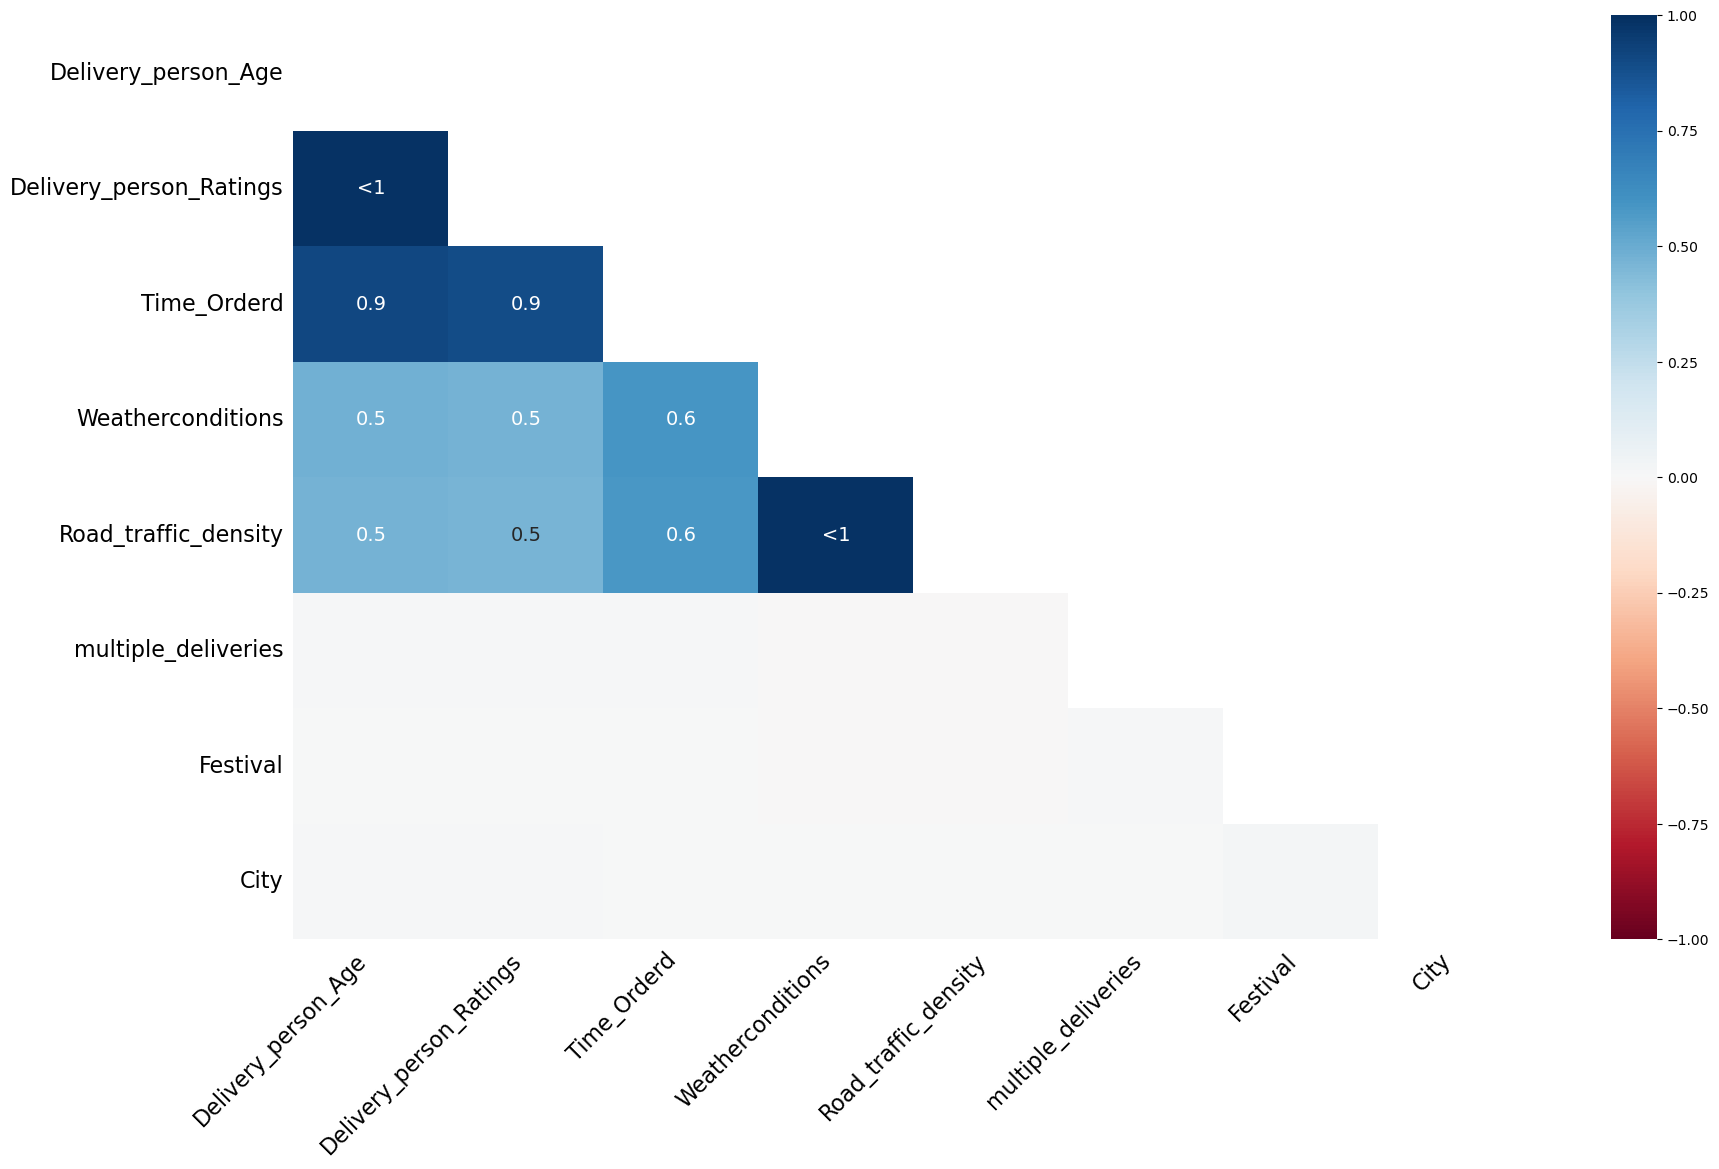

In [29]:
# missing data correlation

msno.heatmap(df)

**Observations**

1. The delivery person columns are correlated to each other. This means that missingness in these columns is highly related which means lack of rider data.
2. The time ordered column is also related to the rider which shows that the data might be missing due to some network error where the system was unable to log rider details and time of order.
3. There is a very high correlation between weather patterns and the road traffic information. Be clear that this does not mean that the road traffic and weather columns are correlated. High corr in missingness means that if value in one column is missing, it is a high chance that it will be missing in others as well.
3. Road traffic density also shows correlation to the rider as it might be provided through the phone of rider (need to investigate).


In [30]:
df[["Weatherconditions","Road_traffic_density"]].isna().sum()

Weatherconditions       616
Road_traffic_density    601
dtype: int64

In [31]:
# prove point of missingness

df_cols = missing_df[["Weatherconditions", "Road_traffic_density"]]

both_missing = df_cols.isna().all(axis=1).sum()
total_missing = df_cols.isna().sum().sum()

result = both_missing / total_missing
print(f"Proportion of jointly missing rows: {result:.2%}")
print("Proportion of jointly missing rows: {:.2f}%".format(result * 100))


Proportion of jointly missing rows: 49.38%
Proportion of jointly missing rows: 49.38%


### Dendrogram

<Axes: >

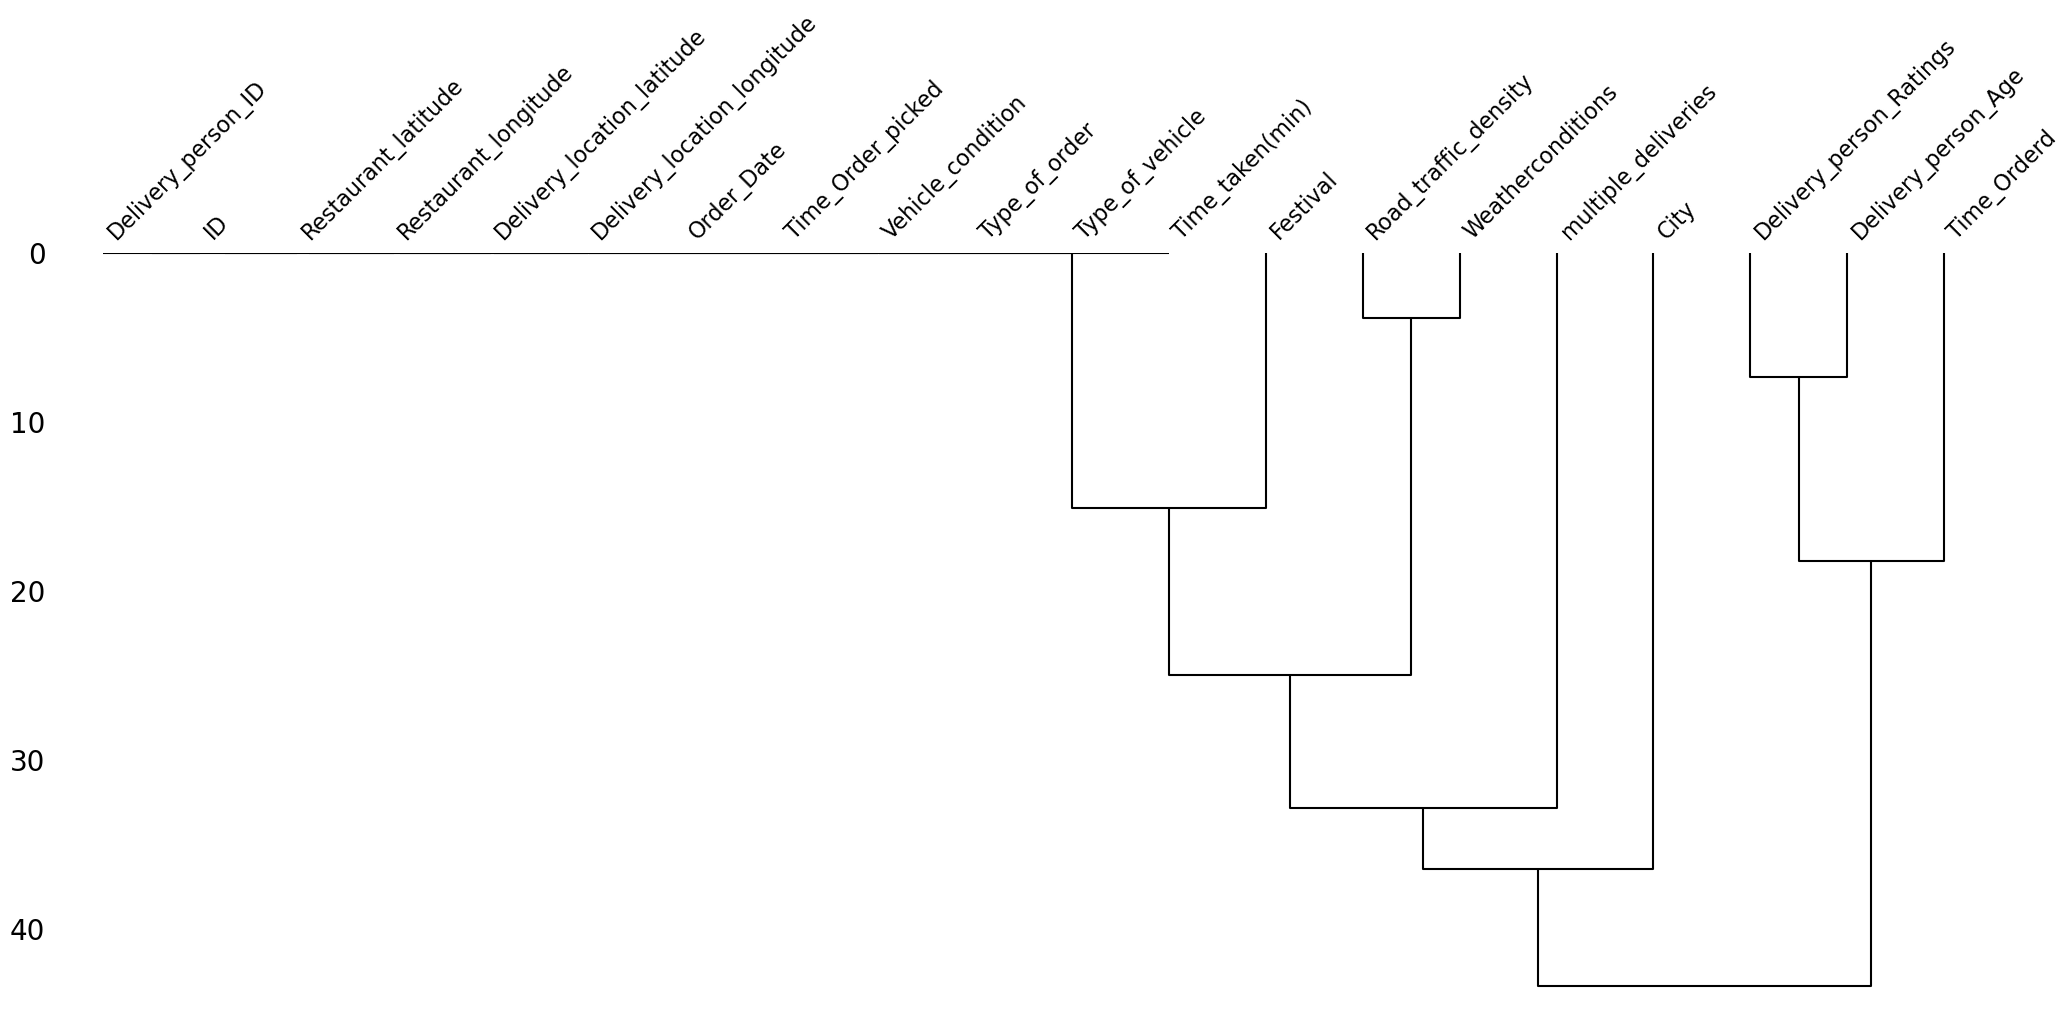

In [32]:
# dendrogram of missingness

msno.dendrogram(df)

In [33]:
# percentage of rows in the data having missing value

(df.isna().any(axis=1).sum() / df.shape[0]) * 100

np.float64(9.266773408198627)

9.27% of the rows in the dataset have at least one missing value.

In [34]:
df.isna().any(axis=1).sum()

np.int64(4225)

In [35]:
df.shape[0]

45593

In [36]:
df.shape

(45593, 20)

**About `9%` of the rows in the data have missing values**

# Basic Data Cleaning

In [37]:
# column names in data
df.columns.to_list()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)']

In [38]:
def change_column_names(data):
    data.columns = data.columns.str.lower()
    return data.rename(columns={
        "delivery_person_id": "rider_id",
        "delivery_person_age": "age",
        "delivery_person_ratings": "ratings",
        "delivery_location_latitude": "delivery_latitude",
        "delivery_location_longitude": "delivery_longitude",
        "time_orderd": "order_time",
        "time_order_picked": "order_picked_time",
        "weatherconditions": "weather",
        "road_traffic_density": "traffic",
        "city": "city_type",
        "time_taken(min)": "time_taken"
    })

In [39]:
# change column names

df = change_column_names(df)

In [40]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
# check for duplicate rows

df.drop(columns=["id","rider_id"]).duplicated().sum()

np.int64(0)

In [43]:
df.shape

(45593, 20)

**There are no duplicate rows in the data**

## Column Wise Cleaning

### ID

In [44]:
# unique items in ID column

print(f"The number of unique IDs are {df['id'].nunique()}")

The number of unique IDs are 45593


In [45]:
df['id'].dtype

dtype('O')

**All the ID values are unique**

This column can be dropped from the data

### Rider Id

In [46]:
df['rider_id'].dtype

dtype('O')

In [47]:
# unique rider ids in the column

df['rider_id'].nunique()

1320

**The data contains 1320 unique riders**

In [48]:
# rider order count in data

df['rider_id'].value_counts().head(10)

rider_id
JAPRES11DEL02        67
PUNERES01DEL01       67
RANCHIRES02DEL01     66
VADRES08DEL02        66
JAPRES03DEL01        66
HYDRES04DEL02        66
VADRES11DEL02        66
JAPRES09DEL02        65
RANCHIRES02DEL02     65
BANGRES03DEL01       65
Name: count, dtype: int64

In [49]:
df['rider_id'].str.split("RES").sample(10)

12467      [CHEN, 02DEL02 ]
26542       [HYD, 13DEL03 ]
38160    [RANCHI, 20DEL03 ]
32560       [VAD, 04DEL02 ]
44547       [HYD, 08DEL03 ]
27010    [RANCHI, 01DEL03 ]
45049      [BANG, 16DEL03 ]
16905     [BANG, 010DEL01 ]
1743       [INDO, 05DEL01 ]
22892       [SUR, 18DEL03 ]
Name: rider_id, dtype: object

In [50]:
# extract city name out of rider id

df['city_name'] = df['rider_id'].str.split("RES").str.get(0)
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24,INDO
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33,BANG
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26,BANG
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21,COIMB
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30,CHEN


### Age

In [51]:
# datatype

df['age'].dtype

dtype('O')

In [52]:
df['age'] = df['age'].astype(float)

In [53]:
# min, mean and max values

df['age'].describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

In [54]:
df['age'].dtype

dtype('float64')

In [55]:
df['age'].isnull().sum()

np.int64(1854)

**Minimum Rider age of 15 is concerning**

Investigate further what type of transport is he using?

<Axes: ylabel='age'>

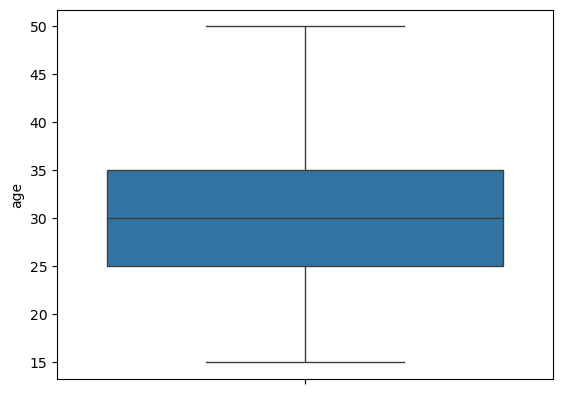

In [56]:
# boxplot of the age column

sns.boxplot(df['age'])

In [57]:
# rows of data where rider age is less than 18(minor)


minors_data = df[df['age'] < 18]

minors_data

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
2387,0x564,JAPRES15DEL03,15.0,1,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,17:20:00,NaN,NaN,3,Meal,motorcycle,0,No,Urban,(min) 15,JAP
2905,0xcd0,INDORES010DEL03,15.0,1,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,20:30:00,NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 29,INDO
2951,0x91a,SURRES17DEL03,15.0,1,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,22:10:00,NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 20,SUR
5902,0x474,CHENRES15DEL03,15.0,1,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50:00,NaN,NaN,3,Drinks,bicycle,1,No,Metropolitian,(min) 25,CHEN
9156,0x73f,BANGRES05DEL01,15.0,1,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,23:25:00,NaN,NaN,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34,BANG
10900,0x1b49,MUMRES14DEL02,15.0,1,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,20:55:00,NaN,NaN,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39,MUM
11125,0x40b,SURRES12DEL01,15.0,1,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30:00,NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 27,SUR
12093,0x523,INDORES03DEL02,15.0,1,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,21:15:00,NaN,NaN,3,Buffet,bicycle,0,No,Metropolitian,(min) 28,INDO
15124,0x18b0,RANCHIRES02DEL01,15.0,1,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55:00,NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 21,RANCHI
15927,0x550,CHENRES08DEL02,15.0,1,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,18:10:00,NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 17,CHEN


**Observations**:

1. The star ratings of all the riders is 1.
2. The vehicle condition of these riders is very bad.
3. No weather and traffic conditions available.
4. Age of all these riders is 15 which is below the permissable age to drive a vehicle.
5. Latitude and Longitude values in negative which is not possible. India is situated above the equator so all latitudes should be positive and east of meridian line so longitudes are positive as well.

**Seems like removing this data for now makes more sense then fixing it because a lot of data is missing**

In [58]:
# rows of minors

minor_index = minors_data.index.to_list()

len(minor_index)


38

In [59]:
df.drop(index = minor_index , inplace = True)

In [60]:
df.shape

(45555, 21)

In [61]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24,INDO
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33,BANG
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26,BANG
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21,COIMB
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30,CHEN


### Ratings

In [62]:
# datatype

df['ratings'].dtype

dtype('O')

In [63]:
# min, mean and max values

df['ratings'] = df['ratings'].astype(float)

In [64]:
df['ratings'].describe()

count    43647.000000
mean         4.636944
std          0.317217
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

In [65]:
df['ratings'].dtype

dtype('float64')

**6 Star rating is possibly a data error**

<Axes: ylabel='ratings'>

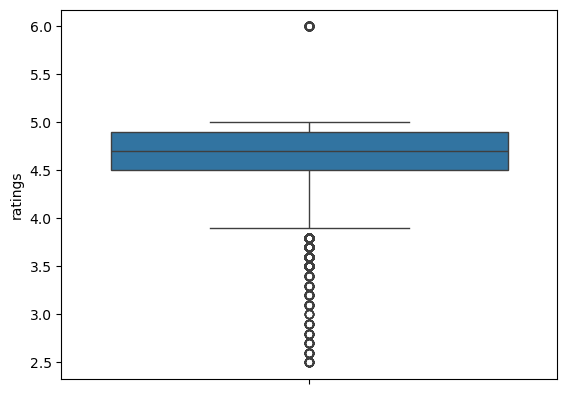

In [66]:
# boxplot

sns.boxplot(df['ratings'])

1. **The Minors data have ratings as 1 which seems like an anomaly if we generally consider the ratings column distribution.**

2. **The rating of 6 is also one another anomaly in the data as maximum ratings are 5 and not more than that**
    - Has to be investigated
    - If data is problematic than fixing or removing is an option

In [67]:
# rows where the star rating is 6

six_star_data = df[df['ratings'] > 5]

len(six_star_data)

53

In [68]:
six_star_data

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
3586,0x46d,BANGRES05DEL01,50.0,6.0,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 25,BANG
4714,0x493,HYDRES17DEL01,50.0,6.0,-17.451976,-78.385883,17.561976,78.495883,04-04-2022,NaN,23:20:00,NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 27,HYD
5169,0x4f2,JAPRES08DEL01,50.0,6.0,-26.910262,-75.783013,27.020262,75.893013,18-03-2022,NaN,18:50:00,NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20,JAP
5362,0x430,BANGRES19DEL01,50.0,6.0,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:55:00,NaN,NaN,3,Meal,electric_scooter,1,No,Metropolitian,(min) 18,BANG
5651,0xbef1,AGRRES13DEL02,50.0,6.0,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:00,NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20,AGR
6394,0x427,JAPRES06DEL02,50.0,6.0,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:10:00,NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 20,JAP
7031,0x3eb,MYSRES15DEL02,50.0,6.0,-12.352058,-76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:00,NaN,NaN,3,Buffet,scooter,1,No,Metropolitian,(min) 14,MYS
7681,0xd42,VADRES09DEL01,50.0,6.0,0.000000,0.000000,0.010000,0.010000,21-03-2022,NaN,08:35:00,NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 22,VAD
9499,0x3f0,BANGRES010DEL01,50.0,6.0,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:25:00,NaN,NaN,3,Drinks,scooter,1,No,Urban,(min) 17,BANG
9535,0x3ef,RANCHIRES13DEL01,50.0,6.0,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,17:55:00,NaN,NaN,3,Snack,bicycle,1,No,Metropolitian,(min) 32,RANCHI


In [69]:
df.shape

(45555, 21)

In [70]:
six_star_index = six_star_data.index.tolist()


In [71]:
df.drop(index = six_star_index , inplace = True)

In [72]:
df.shape

(45502, 21)

**Investigate further before action**

Data removal seems logical at this stage.

### Location Columns

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45502 entries, 0 to 45592
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    45502 non-null  object 
 1   rider_id              45502 non-null  object 
 2   age                   43648 non-null  float64
 3   ratings               43594 non-null  float64
 4   restaurant_latitude   45502 non-null  float64
 5   restaurant_longitude  45502 non-null  float64
 6   delivery_latitude     45502 non-null  float64
 7   delivery_longitude    45502 non-null  float64
 8   order_date            45502 non-null  object 
 9   order_time            43862 non-null  object 
 10  order_picked_time     45502 non-null  object 
 11  weather               44977 non-null  object 
 12  traffic               44992 non-null  object 
 13  vehicle_condition     45502 non-null  int64  
 14  type_of_order         45502 non-null  object 
 15  type_of_vehicle       45

In [74]:
location_columns = df.columns[4:8].tolist()

location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [75]:
location_subset = df.loc[:,location_columns]
location_subset.head(10)

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
5,17.431668,78.408321,17.461668,78.438321
6,23.369746,85.339820,23.479746,85.449820
7,12.352058,76.606650,12.482058,76.736650
8,17.433809,78.386744,17.563809,78.516744
9,30.327968,78.046106,30.397968,78.116106


**Valid values for lat and long**

 > India lies to the north of the equator between `6° 44′` and `35° 30′` north latitude and `68° 7′` and `97° 25′` east longitude.

In [76]:
# statistical analysis

location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45502.000000,45502.000000,45502.000000,45502.000000
mean,17.046293,70.326557,17.468434,70.848718
std,8.131457,22.591753,7.334058,21.111306
min,-30.905562,-88.352885,0.010000,0.010000
25%,12.933284,73.170283,12.988453,73.280000
50%,18.551440,75.898497,18.634382,76.002471
75%,22.728163,78.045043,22.785049,78.105359
max,30.914057,88.433452,31.054057,88.563452


In [77]:
# set the lower bound limits for the lat and long

lower_bound_lat = 6.44
lower_bound_long = 68.70

In [78]:
# rows of data where latitude and longitude values are below the bounds

df[(df['restaurant_latitude'] < lower_bound_lat) | (df['restaurant_longitude'] < lower_bound_long) |
        (df['delivery_latitude'] < lower_bound_lat) | (df['delivery_longitude'] < lower_bound_long)].sample(10)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
29540,0x4cd,MYSRES11DEL02,NaN,NaN,-12.323225,-76.630028,12.403225,76.710028,16-03-2022,NaN,00:10:00,NaN,NaN,3,Drinks,motorcycle,2,No,Metropolitian,(min) 43,MYS
44595,0x1699,VADRES16DEL01,34.0,4.6,0.000000,0.000000,0.110000,0.110000,16-03-2022,20:50:00,20:55:00,Fog,Jam,2,Meal,scooter,2,Yes,Metropolitian,(min) 49,VAD
36267,0x5cbc,VADRES08DEL01,31.0,4.6,0.000000,0.000000,0.070000,0.070000,25-03-2022,20:40:00,20:55:00,Cloudy,Jam,0,Snack,motorcycle,1,No,Metropolitian,(min) 40,VAD
17613,0x11c4,VADRES07DEL01,28.0,4.8,0.000000,0.000000,0.040000,0.040000,03-04-2022,14:55:00,15:10:00,Stormy,High,0,Buffet,motorcycle,1,No,Metropolitian,(min) 29,VAD
16701,0x2dab,VADRES08DEL02,29.0,4.5,0.000000,0.000000,0.020000,0.020000,28-03-2022,10:25:00,10:35:00,Windy,Low,1,Drinks,scooter,0,No,Urban,(min) 12,VAD
32216,0xd5d5,DEHRES01DEL02,20.0,4.5,0.000000,0.000000,0.020000,0.020000,17-02-2022,10:00:00,10:15:00,Windy,Low,1,Snack,scooter,1,No,Metropolitian,(min) 14,DEH
29035,0xcc8b,ALHRES06DEL01,37.0,5.0,0.000000,0.000000,0.010000,0.010000,15-02-2022,10:10:00,10:25:00,Windy,Low,2,Meal,scooter,1,No,Metropolitian,(min) 23,ALH
28432,0x6c9,VADRES04DEL02,35.0,4.8,0.000000,0.000000,0.130000,0.130000,06-04-2022,17:40:00,17:50:00,Cloudy,Medium,1,Buffet,motorcycle,1,No,Metropolitian,(min) 44,VAD
6402,0xd506,DEHRES11DEL02,23.0,4.5,0.000000,0.000000,0.130000,0.130000,12-02-2022,23:50:00,00:05:00,Cloudy,Low,2,Meal,motorcycle,1,No,Metropolitian,(min) 26,DEH
39879,0xae93,RANCHIRES02DEL01,36.0,4.6,0.000000,0.000000,0.010000,0.010000,24-03-2022,09:55:00,10:00:00,Stormy,Low,1,Buffet,motorcycle,0,No,Urban,(min) 25,RANCHI


In [79]:
# number of rows in data where lat long are erroneous

location_subset[(location_subset['restaurant_latitude'] < lower_bound_lat) |
                    (location_subset['restaurant_longitude'] < lower_bound_long) |
                    (location_subset['delivery_latitude'] < lower_bound_lat) |
                    (location_subset['delivery_longitude'] < lower_bound_long)].shape[0]

4029

**There are 4029 rows in the data where the lat long columns are messy**

In [80]:
# statistical summary of problematic rows where lat long is below the country's geographical limits

location_subset[(location_subset['restaurant_latitude'] < lower_bound_lat) |
                    (location_subset['restaurant_longitude'] < lower_bound_long) |
                    (location_subset['delivery_latitude'] < lower_bound_lat) |
                    (location_subset['delivery_longitude'] < lower_bound_long)].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,4029.000000,4029.000000,4029.000000,4029.000000
mean,-2.024551,2.522899,2.087684,7.764720
std,6.385871,24.383056,6.386195,23.271934
min,-30.905562,-88.352885,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


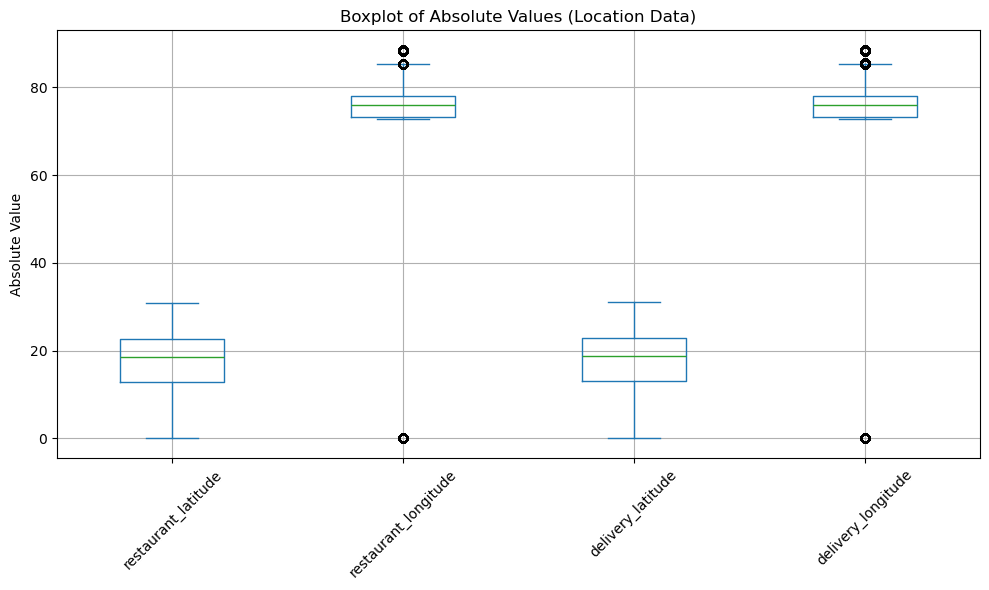

In [81]:
location_subset.abs().plot(kind="box", figsize=(10, 6), grid=True)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add title and labels if needed
plt.title("Boxplot of Absolute Values (Location Data)")
plt.ylabel("Absolute Value")
plt.tight_layout()

# Show plot
plt.show()

**Negative Values are correct just we have to take absolute**

**While calculating the distances we can assign null values to these erroneous data points and then impute the values using advanced imputation techniques**

In [82]:
columns_to_abs = ['restaurant_latitude',
                  'restaurant_longitude',
                  'delivery_latitude',
                  'delivery_longitude']

df[columns_to_abs] = df[columns_to_abs].abs()


In [83]:
df[ ['restaurant_latitude','restaurant_longitude','delivery_latitude','delivery_longitude']].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45502.000000,45502.000000,45502.000000,45502.000000
mean,17.404823,70.785107,17.468434,70.848718
std,7.332705,21.111115,7.334058,21.111306
min,0.000000,0.000000,0.010000,0.010000
25%,12.934179,73.170283,12.988453,73.280000
50%,18.554382,75.898497,18.634382,76.002471
75%,22.732225,78.046106,22.785049,78.105359
max,30.914057,88.433452,31.054057,88.563452


In [84]:
df.loc[df['restaurant_latitude'] < lower_bound_lat, 'restaurant_latitude'].value_counts()

restaurant_latitude
0.0    3630
Name: count, dtype: int64

Every entry in the restaurant_latitude column is less than the expected lower bound and is consistently recorded as 0.

In [85]:
df.loc[df['restaurant_longitude'] < lower_bound_long, 'restaurant_longitude'].value_counts()

restaurant_longitude
0.0    3630
Name: count, dtype: int64

All values in the restaurant_longitude column are less than the expected lower bound and are consistently 0.

In [86]:
df.loc[df['delivery_latitude'] < lower_bound_lat, 'delivery_latitude'].value_counts()

delivery_latitude
0.13    341
0.06    336
0.04    335
0.09    335
0.02    335
0.07    332
0.11    327
0.05    327
0.01    326
0.08    324
0.03    312
Name: count, dtype: int64

All values in the delivery_latitude column fall below the lower expected threshold (< 1), which strongly suggests invalid or corrupted geolocation data.

In [87]:
df.loc[df['delivery_longitude'] < lower_bound_long, 'delivery_longitude'].value_counts()

delivery_longitude
0.13    341
0.06    336
0.04    335
0.09    335
0.02    335
0.07    332
0.11    327
0.05    327
0.01    326
0.08    324
0.03    312
Name: count, dtype: int64

All values in the delivery_longitude column fall below the lower expected threshold (< 1), which strongly suggests invalid or corrupted geolocation data.

In [88]:
df[(df['restaurant_latitude'] < lower_bound_lat) | (df['restaurant_longitude'] < lower_bound_long) |
                     (df['delivery_latitude'] < lower_bound_lat) |
                     (df['delivery_longitude'] < lower_bound_long)].shape

(3630, 21)

**`3630` rows in the data that have messy lat long values**

**All the messy lat long values are less than 1**

In [89]:
df.isnull().sum()

id                         0
rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude        0
restaurant_longitude       0
delivery_latitude          0
delivery_longitude         0
order_date                 0
order_time              1640
order_picked_time          0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
dtype: int64

In [90]:
def clean_lat_long(data, threshold=1):
    # Get the list of location columns (like latitudes and longitudes)
    location_columns = location_subset.columns.tolist()
    
    # For each location column, set values < threshold to NaN
    for col in location_columns:
        data[col] = data[col].apply(lambda x: np.nan if x < threshold else x)
    
    return data


In [91]:
clean_lat_long(df).head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24,INDO
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33,BANG
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26,BANG
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21,COIMB
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30,CHEN


In [92]:
df.isnull().sum()

id                         0
rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
order_time              1640
order_picked_time          0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
dtype: int64

In [93]:
df.shape

(45502, 21)

In [94]:
import pandas as pd
import numpy as np

# Select relevant columns to clean
columns_to_abs = ['restaurant_latitude', 'restaurant_longitude',
                  'delivery_latitude', 'delivery_longitude']

# Clean function to remove invalid geo values
def clean_lat_long(df, threshold=1):
    df['time_taken'] = df['time_taken'].str.replace(r"\(min\)", "", regex=True).str.strip().astype(float)
    df[columns_to_abs] = df[columns_to_abs].abs()
    location_columns = columns_to_abs
    for col in location_columns:
        df[col] = df[col].apply(lambda x: np.nan if x < threshold else x)
    return df

# Apply cleaning
df_cleaned = clean_lat_long(df)


In [95]:
!pip install folium

In [96]:
df.dtypes

id                       object
rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
order_time               object
order_picked_time        object
weather                  object
traffic                  object
vehicle_condition         int64
type_of_order            object
type_of_vehicle          object
multiple_deliveries      object
festival                 object
city_type                object
time_taken              float64
city_name                object
dtype: object

In [97]:
import pandas as pd
import numpy as np
import folium
import webbrowser

# Select relevant columns to clean
columns_to_abs = ['restaurant_latitude', 'restaurant_longitude',
                  'delivery_latitude', 'delivery_longitude']

# Clean function to remove invalid geo values
def clean_lat_long(df, threshold=1):
    df['time_taken'] = df['time_taken'].astype(str).str.replace(r"\(min\)", "", regex=True).str.strip().astype(float)
    df[columns_to_abs] = df[columns_to_abs].abs()
    for col in columns_to_abs:
        df[col] = df[col].apply(lambda x: np.nan if x < threshold else x)
    return df

# Apply cleaning
df_cleaned = clean_lat_long(df)

# Compute group-wise averages by city_type
avg_metrics_by_city = df_cleaned.groupby('city_type').agg({
    'time_taken': 'mean',
    'ratings': 'mean'
}).round(1)

# Drop rows with missing location or city_type
df_cleaned = df_cleaned.dropna(subset=['delivery_latitude', 'delivery_longitude', 'city_type'])

# Initialize map at the center
mean_lat = df_cleaned['delivery_latitude'].mean()
mean_lon = df_cleaned['delivery_longitude'].mean()
delivery_map = folium.Map(location=[mean_lat, mean_lon], zoom_start=12)

# Add markers with hover
for _, row in df_cleaned.iterrows():
    city = row['city_type']
    avg_time = avg_metrics_by_city.loc[city, 'time_taken'] if city in avg_metrics_by_city.index else 'N/A'
    avg_rating = avg_metrics_by_city.loc[city, 'ratings'] if city in avg_metrics_by_city.index else 'N/A'
    
    tooltip_text = f"""
    🏙️ <b>City:</b> {city}<br>
    ⏱️ <b>Avg Time Taken:</b> {avg_time} min<br>
    ⭐ <b>Avg Rating:</b> {avg_rating}
    """
    
    folium.CircleMarker(
        location=[row['delivery_latitude'], row['delivery_longitude']],
        radius=3,
        color='purple',
        fill=True,
        fill_opacity=0.6,
        tooltip=folium.Tooltip(tooltip_text, sticky=True)
    ).add_to(delivery_map)

# Save map to file and open in browser
delivery_map.save("delivery_map.html")
webbrowser.open("delivery_map.html")

True

### Order Date

In [98]:
df['order_date'].dtype

dtype('O')

In [99]:
# check for missing values

df['order_date'].isna().sum()

np.int64(0)

In [100]:
# unique values in order date

df['order_date'].unique()

array(['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022',
       '11-03-2022', '04-03-2022', '14-03-2022', '20-03-2022',
       '12-02-2022', '13-02-2022', '14-02-2022', '02-04-2022',
       '01-03-2022', '16-03-2022', '15-02-2022', '10-03-2022',
       '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
       '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022',
       '28-03-2022', '18-03-2022', '06-04-2022', '04-04-2022',
       '24-03-2022', '09-03-2022', '02-03-2022', '13-03-2022',
       '29-03-2022', '31-03-2022', '17-03-2022', '07-03-2022',
       '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
       '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022'],
      dtype=object)

In [101]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)


In [102]:
df['order_date'].unique()

<DatetimeArray>
['2022-03-19 00:00:00', '2022-03-25 00:00:00', '2022-04-05 00:00:00',
 '2022-03-26 00:00:00', '2022-03-11 00:00:00', '2022-03-04 00:00:00',
 '2022-03-14 00:00:00', '2022-03-20 00:00:00', '2022-02-12 00:00:00',
 '2022-02-13 00:00:00', '2022-02-14 00:00:00', '2022-04-02 00:00:00',
 '2022-03-01 00:00:00', '2022-03-16 00:00:00', '2022-02-15 00:00:00',
 '2022-03-10 00:00:00', '2022-03-27 00:00:00', '2022-03-12 00:00:00',
 '2022-04-01 00:00:00', '2022-03-05 00:00:00', '2022-02-11 00:00:00',
 '2022-03-08 00:00:00', '2022-04-03 00:00:00', '2022-03-30 00:00:00',
 '2022-03-28 00:00:00', '2022-03-18 00:00:00', '2022-04-06 00:00:00',
 '2022-04-04 00:00:00', '2022-03-24 00:00:00', '2022-03-09 00:00:00',
 '2022-03-02 00:00:00', '2022-03-13 00:00:00', '2022-03-29 00:00:00',
 '2022-03-31 00:00:00', '2022-03-17 00:00:00', '2022-03-07 00:00:00',
 '2022-03-15 00:00:00', '2022-02-16 00:00:00', '2022-03-03 00:00:00',
 '2022-02-18 00:00:00', '2022-03-23 00:00:00', '2022-02-17 00:00:00',
 '20

In [103]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24.0,INDO
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33.0,BANG
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26.0,BANG
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21.0,COIMB
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30.0,CHEN


In [104]:
# date range

order_date = df['order_date']

order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [105]:
order_date.agg(["min","max"])

min   2022-02-11
max   2022-04-06
Name: order_date, dtype: datetime64[ns]

In [106]:
def extract_datetime_features(series):
    # Create a new DataFrame with extracted date features
    dates = series
    features = pd.DataFrame()
    features['day'] = dates.dt.day
    features['month'] = dates.dt.month
    features['year'] = dates.dt.year
    features['day_of_week'] = dates.dt.day_name()
    features['is_weekend'] = features['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
    
    return features


In [107]:
date_features = extract_datetime_features(df['order_date'])

In [108]:
df = pd.concat([df , date_features] , axis = 1)

In [109]:
df.head(10)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,day,month,year,day_of_week,is_weekend
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24.0,INDO,19,3,2022,Saturday,1
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33.0,BANG,25,3,2022,Friday,0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26.0,BANG,19,3,2022,Saturday,1
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21.0,COIMB,5,4,2022,Tuesday,0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30.0,CHEN,26,3,2022,Saturday,1
5,0x9bb4,HYDRES09DEL03,22.0,4.8,17.431668,78.408321,17.461668,78.438321,2022-03-11,21:20:00,21:30:00,Cloudy,Jam,0,Buffet,motorcycle,1,No,Urban,26.0,HYD,11,3,2022,Friday,0
6,0x95b4,RANCHIRES15DEL01,33.0,4.7,23.369746,85.339820,23.479746,85.449820,2022-03-04,19:15:00,19:30:00,Fog,Jam,1,Meal,scooter,1,No,Metropolitian,40.0,RANCHI,4,3,2022,Friday,0
7,0x9eb2,MYSRES15DEL02,35.0,4.6,12.352058,76.606650,12.482058,76.736650,2022-03-14,17:25:00,17:30:00,Cloudy,Medium,2,Meal,motorcycle,1,No,Metropolitian,32.0,MYS,14,3,2022,Monday,0
8,0x1102,HYDRES05DEL02,22.0,4.8,17.433809,78.386744,17.563809,78.516744,2022-03-20,20:55:00,21:05:00,Stormy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,34.0,HYD,20,3,2022,Sunday,1
9,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55:00,22:10:00,Fog,Jam,2,Snack,motorcycle,3,No,Metropolitian,46.0,DEH,12,2,2022,Saturday,1


In [110]:
df.shape

(45502, 26)

### Order time and Order picked time

In [111]:
df['order_time'].unique()

array(['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00',
       '21:20:00', '19:15:00', '17:25:00', '20:55:00', '21:55:00',
       '14:55:00', '17:30:00', '09:20:00', '19:50:00', '20:25:00',
       '20:30:00', '20:40:00', '21:15:00', '20:20:00', '22:30:00',
       '08:15:00', '19:30:00', '12:25:00', '18:35:00', '20:35:00',
       '23:20:00', '23:35:00', '22:35:00', '23:25:00', '13:35:00',
       '21:35:00', '18:55:00', '14:15:00', '11:00:00', '09:45:00',
       '08:40:00', '23:00:00', nan, '19:10:00', '10:55:00', '21:40:00',
       '19:00:00', '16:45:00', '15:10:00', '22:45:00', '22:10:00',
       '20:45:00', '22:50:00', '17:55:00', '09:25:00', '20:15:00',
       '22:25:00', '22:40:00', '23:50:00', '15:25:00', '10:20:00',
       '10:40:00', '15:55:00', '20:10:00', '12:10:00', '15:30:00',
       '10:35:00', '21:10:00', '20:50:00', '12:35:00', '21:00:00',
       '23:40:00', '18:15:00', '18:20:00', '11:45:00', '12:45:00',
       '23:30:00', '10:50:00', '21:25:00', '10:10:00', '1

In [112]:
df.isnull().sum()

id                         0
rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
order_time              1640
order_picked_time          0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
day                        0
month                      0
year                       0
day_of_week                0
is_weekend                 0
dtype: int64

In [113]:
time_subset = df.loc[:,["order_time","order_picked_time"]]
time_subset.head(10)

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
5,21:20:00,21:30:00
6,19:15:00,19:30:00
7,17:25:00,17:30:00
8,20:55:00,21:05:00
9,21:55:00,22:10:00


In [114]:
time_subset[time_subset['order_time'].isnull()].head() 

,order_time,order_picked_time
42,NaN,18:35:00
74,NaN,15:30:00
120,NaN,18:25:00
140,NaN,23:40:00
179,NaN,17:50:00


In [115]:
#time_subset['order_time'] = time_subset['order_time'].replace(NaT, np.NaN)
#time_subset['order_picked_time'] = time_subset['order_picked_time'].replace(NaT, np.NaN)

In [116]:
time_subset['order_time'] = pd.to_datetime(time_subset['order_time'], format="%H:%M:%S", errors='coerce')
time_subset['order_picked_time'] = pd.to_datetime(time_subset['order_picked_time'], format="%H:%M:%S", errors='coerce')



In [117]:
time_subset['order_time'].head(10)

0   1900-01-01 11:30:00
1   1900-01-01 19:45:00
2   1900-01-01 08:30:00
3   1900-01-01 18:00:00
4   1900-01-01 13:30:00
5   1900-01-01 21:20:00
6   1900-01-01 19:15:00
7   1900-01-01 17:25:00
8   1900-01-01 20:55:00
9   1900-01-01 21:55:00
Name: order_time, dtype: datetime64[ns]

In [118]:
time_subset['order_picked_time'].head(10)

0   1900-01-01 11:45:00
1   1900-01-01 19:50:00
2   1900-01-01 08:45:00
3   1900-01-01 18:10:00
4   1900-01-01 13:45:00
5   1900-01-01 21:30:00
6   1900-01-01 19:30:00
7   1900-01-01 17:30:00
8   1900-01-01 21:05:00
9   1900-01-01 22:10:00
Name: order_picked_time, dtype: datetime64[ns]

In [119]:
time_subset[time_subset['order_picked_time'] < time_subset['order_time']].sample(10)

,order_time,order_picked_time
29254,1900-01-01 23:55:00,1900-01-01 00:10:00
18017,1900-01-01 23:50:00,1900-01-01 00:00:00
22089,1900-01-01 23:55:00,1900-01-01 00:05:00
43084,1900-01-01 23:50:00,1900-01-01 00:00:00
7812,1900-01-01 23:55:00,1900-01-01 00:00:00
34976,1900-01-01 23:45:00,1900-01-01 00:00:00
40618,1900-01-01 23:55:00,1900-01-01 00:10:00
5216,1900-01-01 23:50:00,1900-01-01 00:05:00
39093,1900-01-01 23:50:00,1900-01-01 00:05:00
5264,1900-01-01 23:55:00,1900-01-01 00:10:00


In [120]:
# Fix time where picked time is earlier than order time (e.g., past midnight)
#mask = time_subset['order_picked_time'] < time_subset['order_time']
time_subset.loc[time_subset['order_picked_time'] < time_subset['order_time'], 'order_picked_time'] += pd.Timedelta(days=1)

# Calculate pickup time in minutes
time_subset['pickup_time'] = (time_subset['order_picked_time'] - time_subset['order_time']).dt.total_seconds() / 60

# Extract hour from order time
time_subset['order_time_hour'] = time_subset['order_time'].dt.hour

# Define time of day category
def time_of_day(hour):
    if 6 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 19:
        return "evening"
    elif 19 <= hour < 23:
        return "night"
    elif (hour >= 23) or (hour < 6):
        return "late_night"
    else:
        return np.nan

# Apply time of day categorization
time_subset['order_time_of_day'] = time_subset['order_time_hour'].apply(time_of_day)




In [121]:
time_subset.head(10)

,order_time,order_picked_time,pickup_time,order_time_hour,order_time_of_day
0,1900-01-01 11:30:00,1900-01-01 11:45:00,15.0,11.0,morning
1,1900-01-01 19:45:00,1900-01-01 19:50:00,5.0,19.0,night
2,1900-01-01 08:30:00,1900-01-01 08:45:00,15.0,8.0,morning
3,1900-01-01 18:00:00,1900-01-01 18:10:00,10.0,18.0,evening
4,1900-01-01 13:30:00,1900-01-01 13:45:00,15.0,13.0,afternoon
5,1900-01-01 21:20:00,1900-01-01 21:30:00,10.0,21.0,night
6,1900-01-01 19:15:00,1900-01-01 19:30:00,15.0,19.0,night
7,1900-01-01 17:25:00,1900-01-01 17:30:00,5.0,17.0,evening
8,1900-01-01 20:55:00,1900-01-01 21:05:00,10.0,20.0,night
9,1900-01-01 21:55:00,1900-01-01 22:10:00,15.0,21.0,night


In [122]:
time_subset['pickup_time'].value_counts()

pickup_time
5.0     14703
15.0    14610
10.0    14549
Name: count, dtype: int64

In [123]:
time_subset['order_time'] = time_subset['order_time'].dt.time
time_subset['order_picked_time'] = time_subset['order_picked_time'].dt.time

In [124]:
time_subset.head()

,order_time,order_picked_time,pickup_time,order_time_hour,order_time_of_day
0,11:30:00,11:45:00,15.0,11.0,morning
1,19:45:00,19:50:00,5.0,19.0,night
2,08:30:00,08:45:00,15.0,8.0,morning
3,18:00:00,18:10:00,10.0,18.0,evening
4,13:30:00,13:45:00,15.0,13.0,afternoon


In [125]:
time_subset.shape

(45502, 5)

In [126]:
time_subset.drop(columns = ['order_time' , 'order_picked_time'] , axis = 1 , inplace=True)

In [127]:
time_subset.shape

(45502, 3)

In [128]:
df = pd.concat([df , time_subset] , axis = 1)

In [129]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,day,month,year,day_of_week,is_weekend,pickup_time,order_time_hour,order_time_of_day
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24.0,INDO,19,3,2022,Saturday,1,15.0,11.0,morning
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33.0,BANG,25,3,2022,Friday,0,5.0,19.0,night
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26.0,BANG,19,3,2022,Saturday,1,15.0,8.0,morning
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21.0,COIMB,5,4,2022,Tuesday,0,10.0,18.0,evening
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30.0,CHEN,26,3,2022,Saturday,1,15.0,13.0,afternoon


In [130]:
df.shape

(45502, 29)

### Weather

In [131]:
# value counts

df['weather'].value_counts()

weather
Fog           7654
Stormy        7586
Cloudy        7536
Sandstorms    7495
Windy         7422
Sunny         7284
Name: count, dtype: int64

In [132]:
df['weather'].dtype

dtype('O')

In [133]:
# unique values
df['weather'].unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan],
      dtype=object)

In [134]:
df['weather'] = df['weather'].str.lower()
df['weather'].unique()

array(['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan],
      dtype=object)

### Traffic

In [135]:
# value counts

df['traffic'].value_counts()

traffic
Low        15477
Jam        14143
Medium     10947
High        4425
Name: count, dtype: int64

In [136]:
df['traffic'].dtype

dtype('O')

In [137]:
# unique values
df['traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', nan], dtype=object)

In [138]:
df['traffic'] = df['traffic'].str.strip().str.lower()
df['traffic'].unique()

array(['high', 'jam', 'low', 'medium', nan], dtype=object)

### Vehicle Condition

In [139]:
# unique values in column

np.sort(df['vehicle_condition'].unique())

array([0, 1, 2, 3])

In [140]:
df['vehicle_condition'] = df['vehicle_condition'].astype(object)

In [141]:
df['vehicle_condition'].dtype

dtype('O')

### Type of order

In [142]:
# value counts

df['type_of_order'].value_counts()

type_of_order
Snack      11512
Meal       11435
Drinks     11294
Buffet     11261
Name: count, dtype: int64

In [143]:
df['type_of_order'].dtype

dtype('O')

In [144]:
# unique values
df['type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [145]:
df['type_of_order'] = df['type_of_order'].str.strip().str.lower()
df['type_of_order'].unique()

array(['snack', 'drinks', 'buffet', 'meal'], dtype=object)

### Type of vehicle

In [146]:
# value counts

df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           26427
scooter              15244
electric_scooter      3778
bicycle                 53
Name: count, dtype: int64

In [147]:
df['type_of_vehicle'].dtype

dtype('O')

In [148]:
# unique values
df['type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [149]:
df['type_of_vehicle'] = df['type_of_vehicle'].str.strip().str.lower()
df['type_of_vehicle'].unique()

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

### Multiple Deliveries

In [150]:
# datatype of multiple deliveries column

df['multiple_deliveries'].dtype

dtype('O')

In [151]:
# unique values in column

df['multiple_deliveries'].unique()

array(['0', '1', '3', nan, '2'], dtype=object)

In [152]:
df['multiple_deliveries'] = df['multiple_deliveries'].astype(object)

In [153]:
df['multiple_deliveries'].unique()

array(['0', '1', '3', nan, '2'], dtype=object)

### Festival

In [154]:
# unique values in column

df['festival'].unique()

array(['No ', 'Yes ', nan], dtype=object)

In [155]:
df['festival'] = df['festival'].str.strip().str.lower()
df['festival'].unique()

array(['no', 'yes', nan], dtype=object)

### City type

In [156]:
# unique values in city type

df['city_type'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', nan], dtype=object)

In [157]:
df['city_type'] = df['city_type'].str.rstrip().str.lower()

df['city_type'].unique()

array(['urban', 'metropolitian', 'semi-urban', nan], dtype=object)

### Time Taken

In [158]:
# datatype of time taken

df['time_taken'].dtype

dtype('float64')

In [159]:
df['time_taken'].unique()

array([24., 33., 26., 21., 30., 40., 32., 34., 46., 23., 20., 41., 15.,
       36., 39., 18., 38., 47., 12., 22., 25., 35., 10., 19., 11., 28.,
       52., 16., 27., 49., 17., 14., 37., 44., 42., 31., 13., 29., 50.,
       43., 48., 54., 53., 45., 51.])

In [161]:
df['time_taken'] = df['time_taken'].astype(str).str.replace(r"\(min\)", "", regex=True).str.strip().astype(float)


In [162]:
df['time_taken'].dtype

dtype('float64')

## Perform Cleaning and Feature Building

In [163]:
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken',
       'city_name', 'day', 'month', 'year', 'day_of_week', 'is_weekend',
       'pickup_time', 'order_time_hour', 'order_time_of_day'],
      dtype='object')

In [164]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,day,month,year,day_of_week,is_weekend,pickup_time,order_time_hour,order_time_of_day
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,sunny,high,2,snack,motorcycle,0,no,urban,24.0,INDO,19,3,2022,Saturday,1,15.0,11.0,morning
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,stormy,jam,2,snack,scooter,1,no,metropolitian,33.0,BANG,25,3,2022,Friday,0,5.0,19.0,night
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,sandstorms,low,0,drinks,motorcycle,1,no,urban,26.0,BANG,19,3,2022,Saturday,1,15.0,8.0,morning
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,sunny,medium,0,buffet,motorcycle,1,no,metropolitian,21.0,COIMB,5,4,2022,Tuesday,0,10.0,18.0,evening
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,cloudy,high,1,snack,scooter,1,no,metropolitian,30.0,CHEN,26,3,2022,Saturday,1,15.0,13.0,afternoon


In [165]:
df.shape

(45502, 29)

In [166]:
df.drop(columns=['id'], axis=1, inplace=True)


In [167]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,day,month,year,day_of_week,is_weekend,pickup_time,order_time_hour,order_time_of_day
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,sunny,high,2,snack,motorcycle,0,no,urban,24.0,INDO,19,3,2022,Saturday,1,15.0,11.0,morning
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,stormy,jam,2,snack,scooter,1,no,metropolitian,33.0,BANG,25,3,2022,Friday,0,5.0,19.0,night
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,sandstorms,low,0,drinks,motorcycle,1,no,urban,26.0,BANG,19,3,2022,Saturday,1,15.0,8.0,morning
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,sunny,medium,0,buffet,motorcycle,1,no,metropolitian,21.0,COIMB,5,4,2022,Tuesday,0,10.0,18.0,evening
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,cloudy,high,1,snack,scooter,1,no,metropolitian,30.0,CHEN,26,3,2022,Saturday,1,15.0,13.0,afternoon


In [168]:
df.shape

(45502, 28)

In [169]:
location_subset.columns.tolist()

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [170]:
def calculate_haversine_distance(df):
    location_columns = location_subset.columns.tolist()
    lat1 = df[location_columns[0]]
    lon1 = df[location_columns[1]]
    lat2 = df[location_columns[2]]
    lon2 = df[location_columns[3]]

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    distance = 6371 * c

    return (
        df.assign(
            distance = distance)
    )

In [171]:
df = calculate_haversine_distance(df)

In [172]:
df.shape

(45502, 29)

## Validate Data Cleaning

In [173]:
# age column

df['age'].agg(["min","max"])

min    20.0
max    39.0
Name: age, dtype: float64

In [174]:
# ratings column

df['ratings'].agg(["min","max"])

min    2.5
max    5.0
Name: ratings, dtype: float64

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


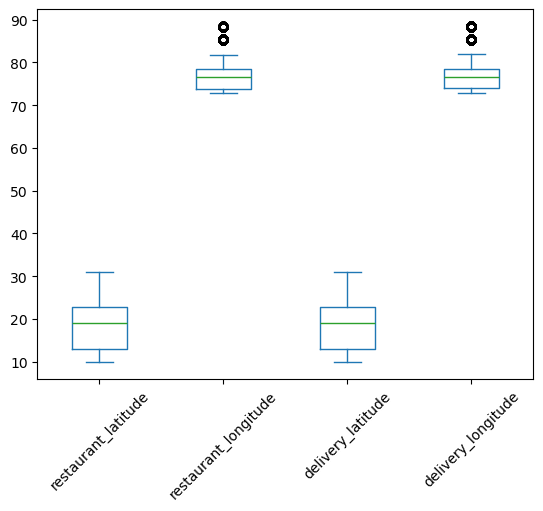

In [175]:
# location columns

df[location_columns].plot(kind="box")

plt.xticks(rotation=45)

display(df[location_columns].describe())

<Axes: >

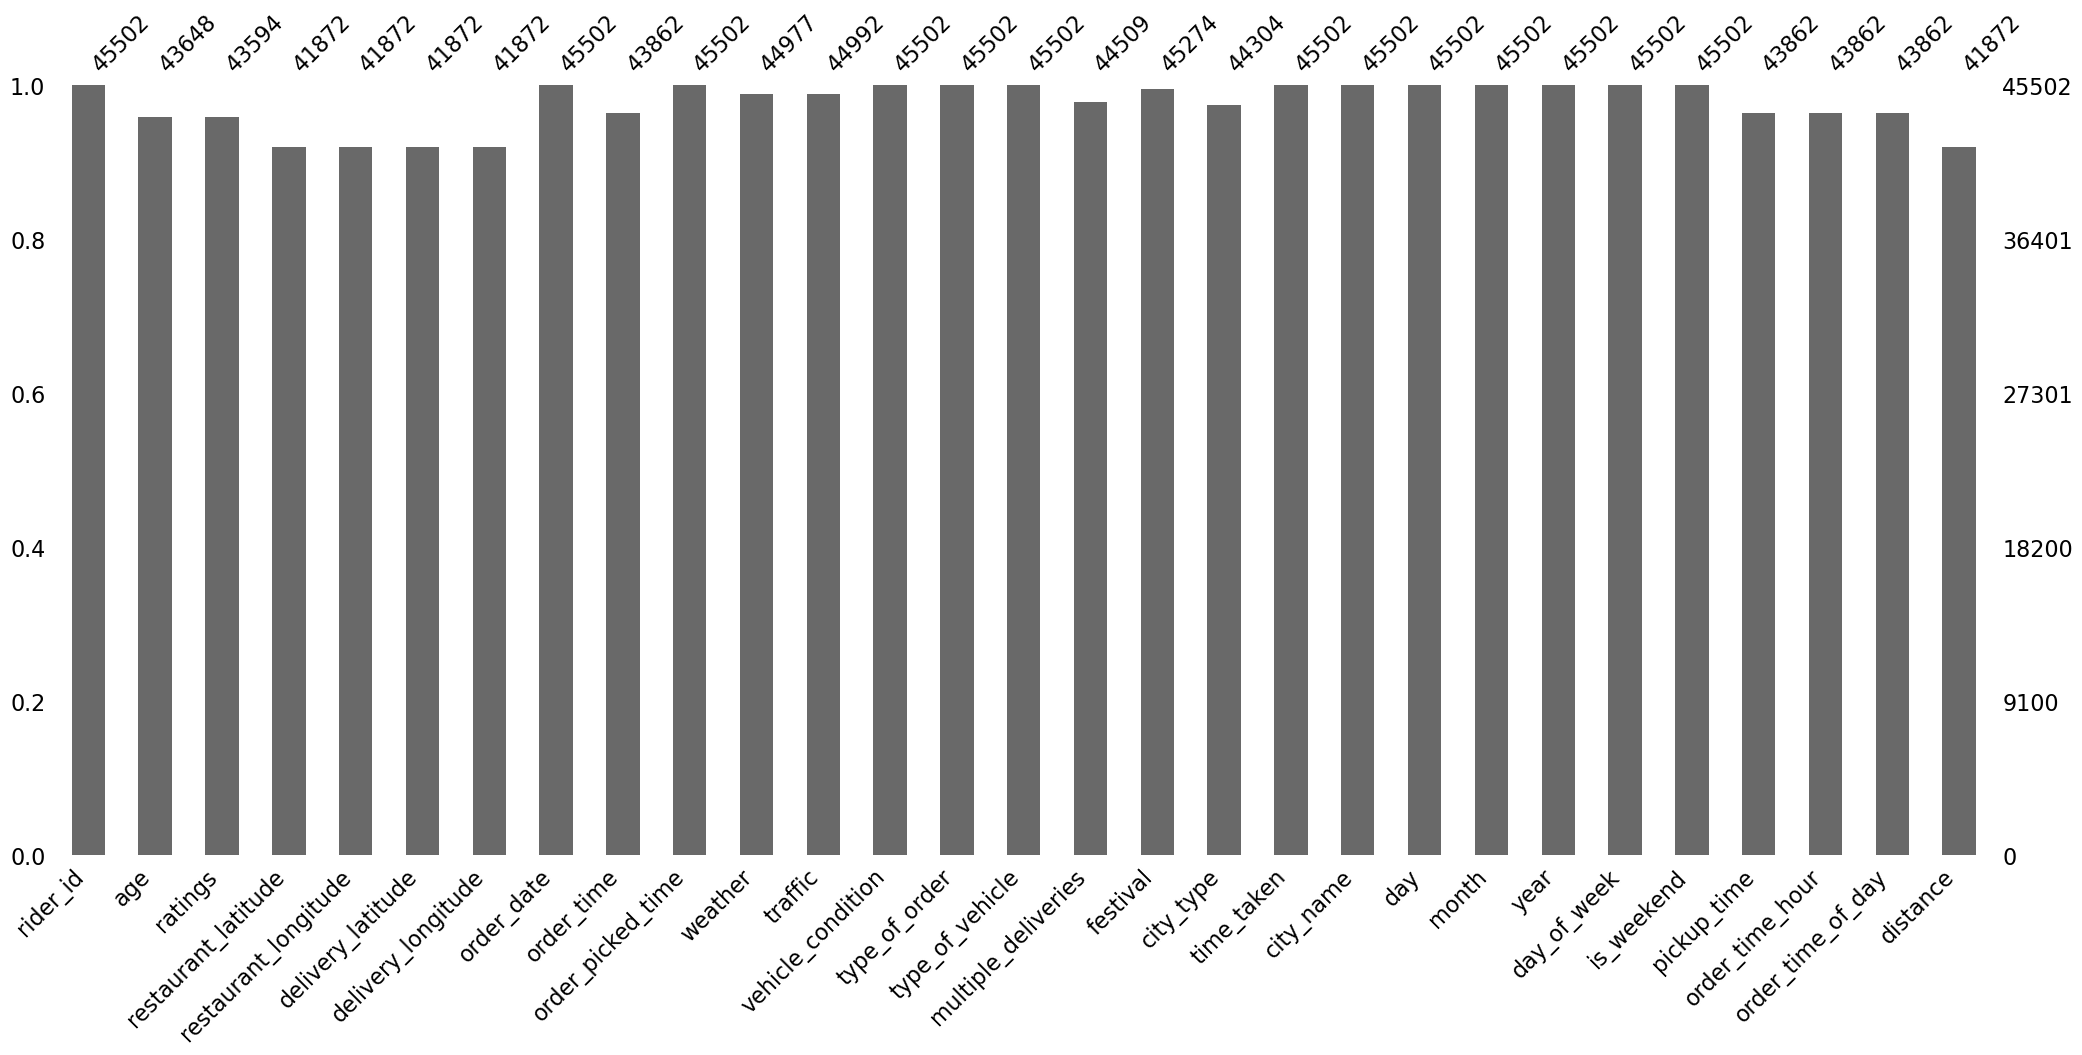

In [176]:
# bar plot of missing values

msno.bar(df)

<Axes: >

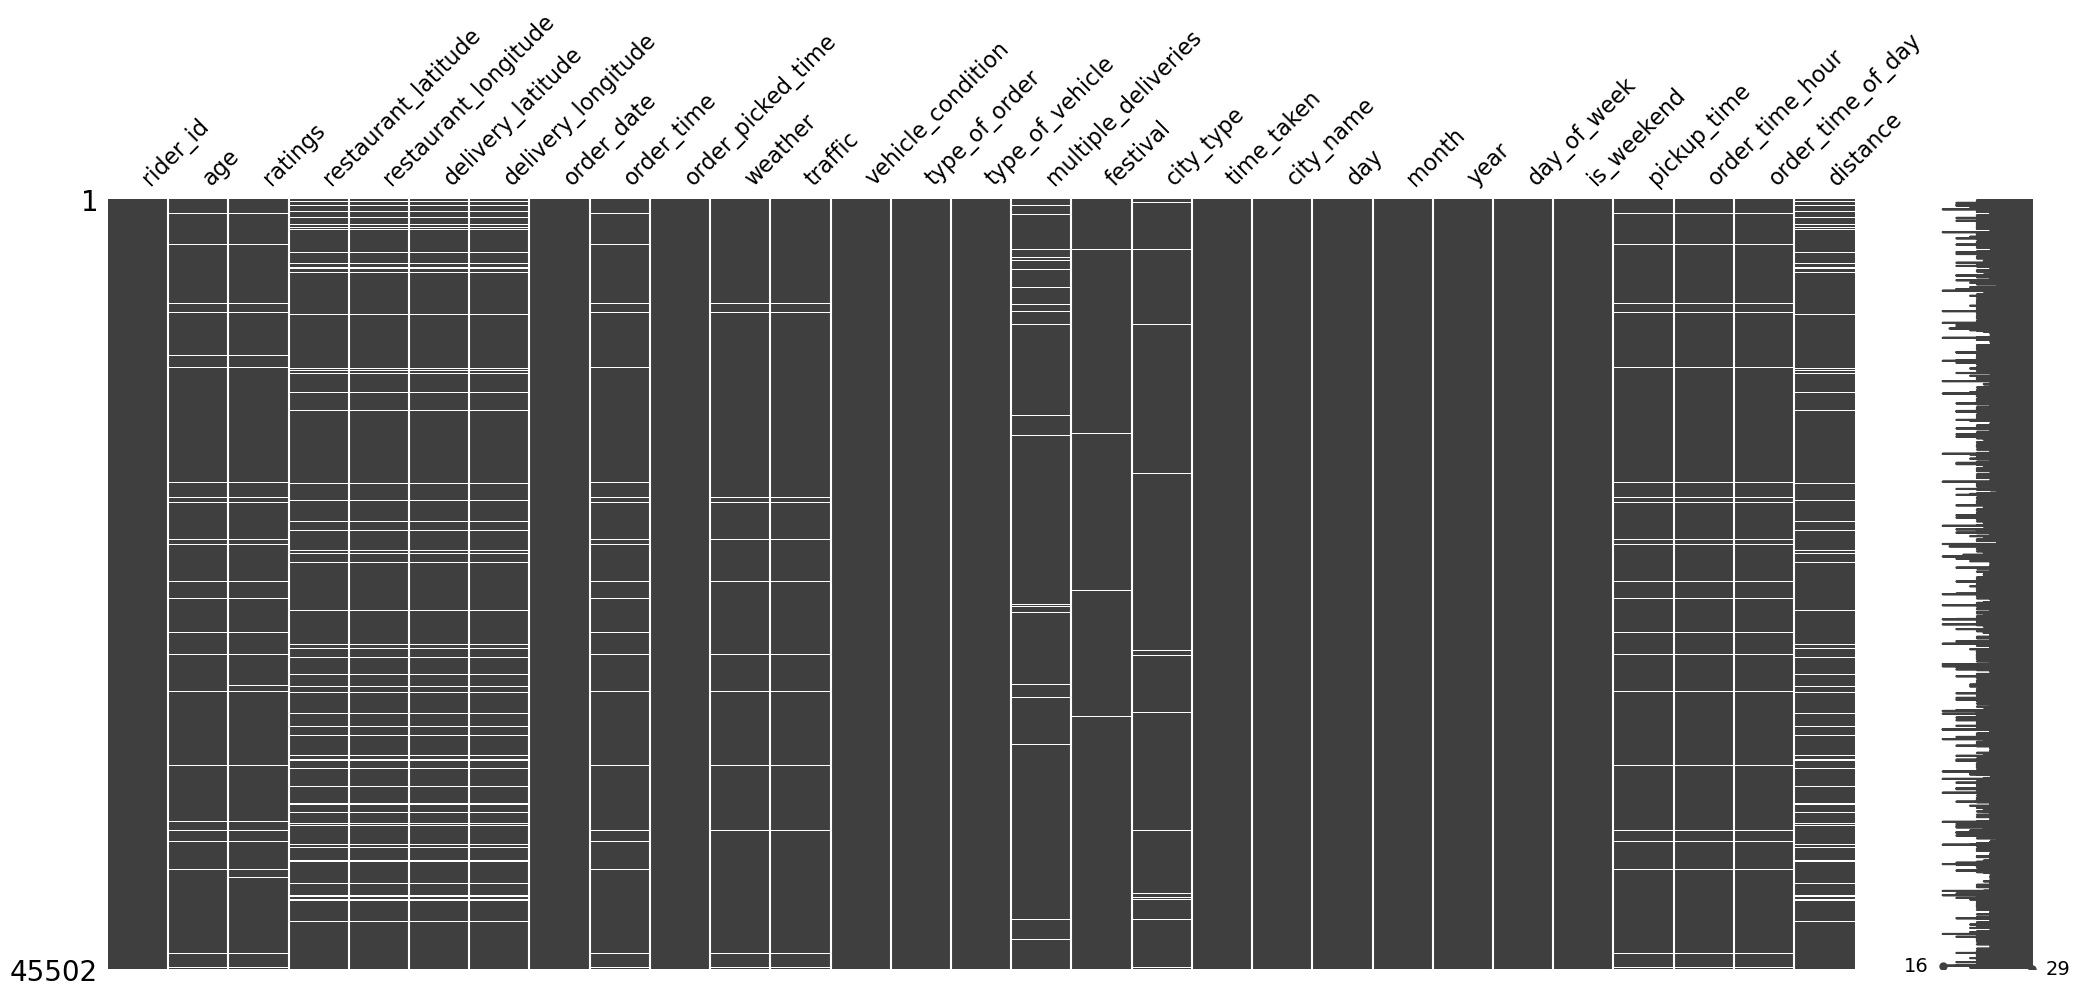

In [177]:
# matrix of missing values

msno.matrix(df)

<Axes: >

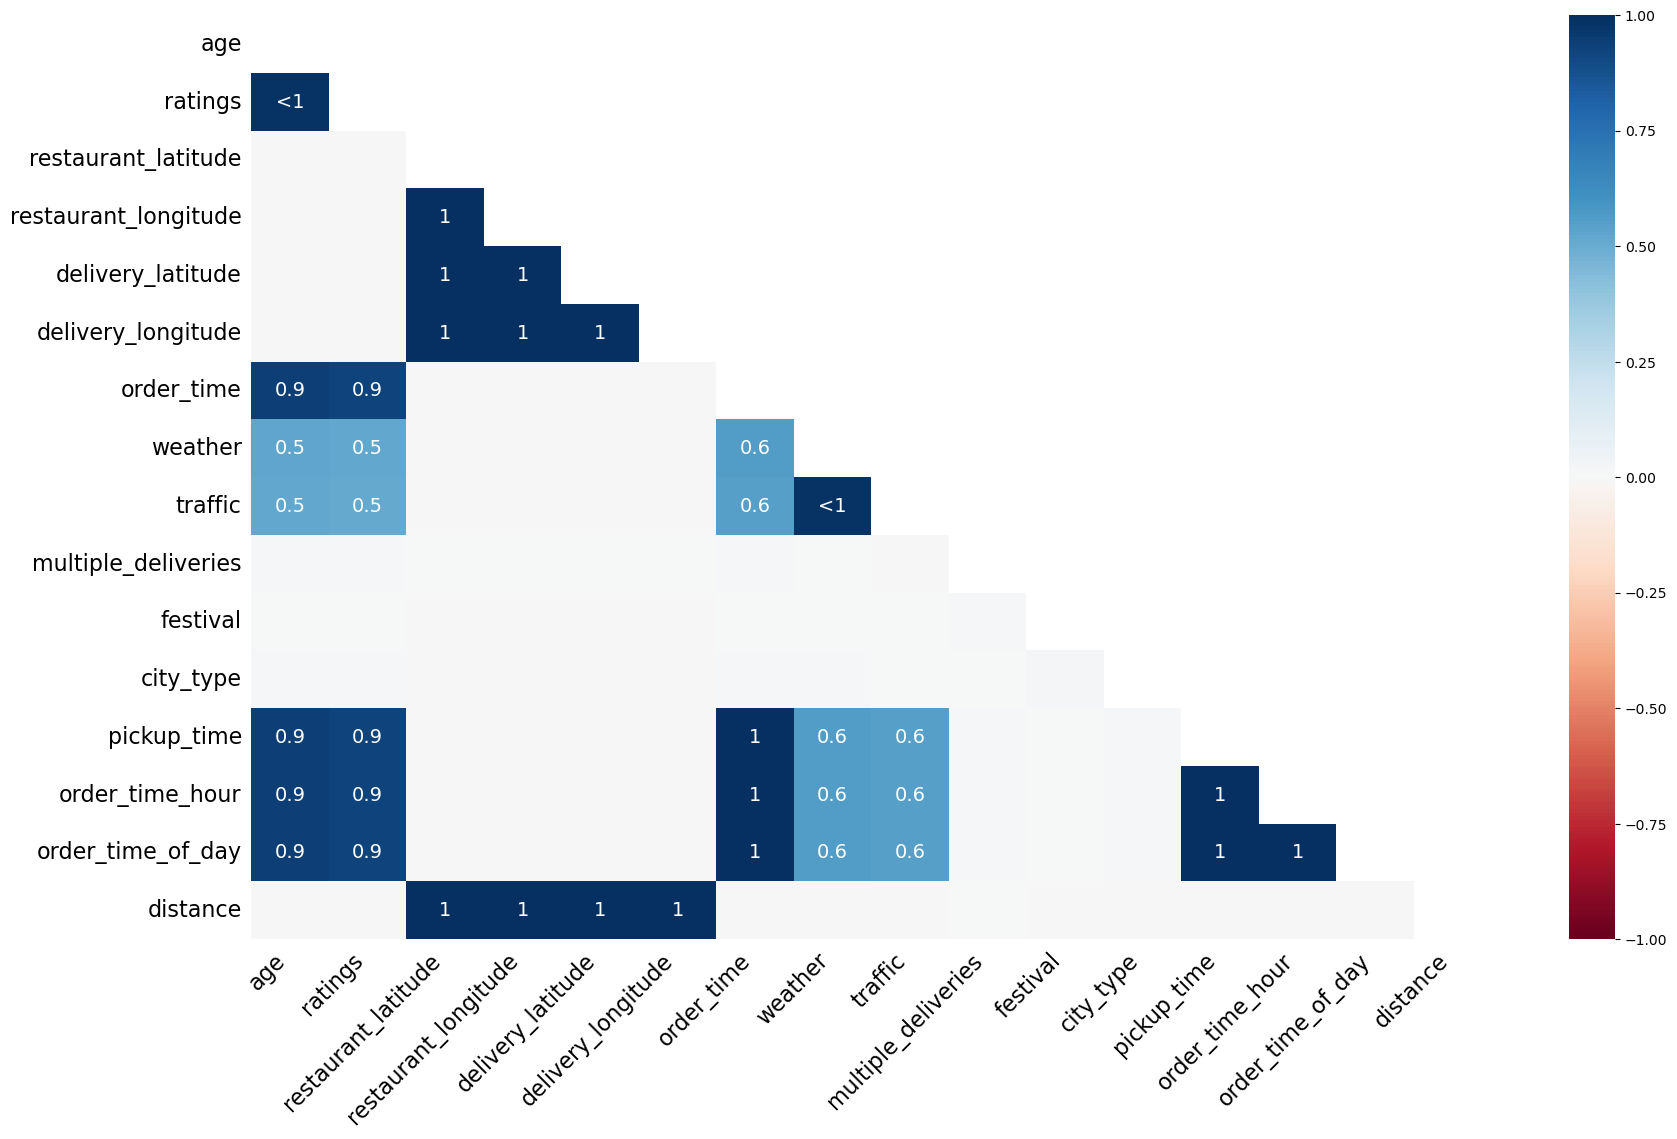

In [178]:
# correlation chart of missing values
msno.heatmap(df)

# Save Cleaned Data

In [179]:
def clean_and_engineer_swiggy_data(df):
    
    # Replace string 'NaN' with np.NaN and clean Weatherconditions
    df = df.replace("NaN ", np.NaN)
    df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "").replace("NaN", np.NaN)
    print(f"{df.shape} original shape of data")
    
    # Rename columns
    df.columns = df.columns.str.lower()
    df = df.rename(columns={
        "delivery_person_id": "rider_id",
        "delivery_person_age": "age",
        "delivery_person_ratings": "ratings",
        "delivery_location_latitude": "delivery_latitude",
        "delivery_location_longitude": "delivery_longitude",
        "time_orderd": "order_time",
        "time_order_picked": "order_pickup_time",
        "weatherconditions": "weather",
        "road_traffic_density": "traffic",
        "city": "city_type",
        "time_taken(min)": "time_taken"
    })

    # Extract city name and clean invalid data
    df['city_name'] = df['rider_id'].str.split("RES").str.get(0)
    print(f"{df.shape} after creating city_name columns from rider_id")
    
    # removing age less than 18 , because less than 18 age person is not able to work as per rules
    # there are 38 such rows where age is less than 18
    df['age'] = df['age'].astype(float)
    minors_data = df[df['age'] < 18]
    minor_index = minors_data.index.to_list()
    df.drop(index = minor_index , inplace = True)
    print(f"{df.shape} after dropping 38 rows of age column")

    
    # removing ratings greater than 5 because , gretaer than 5 rating genrally didn't accepted
    # there are 53 such rows where ratings is greater than 5
    df['ratings'] = df['ratings'].astype(float)
    six_star_data = df[df['ratings'] > 5]
    six_star_index = six_star_data.index.to_list()
    df.drop(index = six_star_index , inplace = True)
    print(f"{df.shape} after droping 53 + 38 rows of ratings and age columns")
    #df = df[df['ratings'] <= 5]
    

    # Clean location columns
    location_cols = ['restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude']
    df[location_cols] = df[location_cols].abs()
    # Every entry in the restaurant_latitude and longitude column is less than the expected lower bound and is consistently 
    # recorded as 0.
    # All values in the delivery_latitude and delivery_longitude column fall below the lower expected threshold (< 1), which strongly 
    # suggests invalid or corrupted geolocation data , there are 3630 such rows with messy lat long values.
    for col in location_cols:
        df[col] = df[col].apply(lambda x: np.nan if x < 1 else x)
    print(f"{df.shape} after latitude and longitude columns")
    

    # Extract date features
    df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
    df['order_day'] = df['order_date'].dt.day
    df['order_month'] = df['order_date'].dt.month
    df['order_year'] = df['order_date'].dt.year
    df['order_day_of_week'] = df['order_date'].dt.day_name()
    df['is_weekend'] = df['order_day_of_week'].isin(['Saturday', 'Sunday'])
    df['is_weekend'] = df['is_weekend'].astype(object)
    print(f"{df.shape} after creating 5 new columns from order_date")
    

    # Time feature engineering
    df['order_time'] = pd.to_datetime(df['order_time'], format="%H:%M:%S", errors='coerce')
    df['order_pickup_time'] = pd.to_datetime(df['order_pickup_time'], format="%H:%M:%S", errors='coerce')
    df.loc[df['order_pickup_time'] < df['order_time'], 'order_pickup_time'] += pd.Timedelta(days=1)
    df['pickup_time'] = (df['order_pickup_time'] - df['order_time']).dt.total_seconds() / 60
    df['order_time_hour'] = df['order_time'].dt.hour
    
        
    def time_of_day(hour):
        if 6 <= hour < 12:
            return "morning"
        elif 12 <= hour < 17:
            return "afternoon"
        elif 17 <= hour < 19:
            return "evening"
        elif 19 <= hour < 23:
            return "night"
        elif (hour >= 23) or (hour < 6):
            return "late_night"
        else:
            return np.nan

    df['order_time_of_day'] = df['order_time_hour'].apply(time_of_day)
    df['order_time'] = df['order_time'].dt.time
    df['order_pickup_time'] = df['order_pickup_time'].dt.time
    print(f"{df.shape} after creating 3 new columns from order_time and order_picked_time")
    

    # Clean and standardize categorical columns
    df['weather'] = df['weather'].str.lower()
    df['traffic'] = df['traffic'].str.strip().str.lower()
    
     # Most riders' vehicles are classified into three main condition levels — 0, 1, and 2 — and all of them appear almost 
    # equally in the data. But there's a very small number of vehicles marked with condition ‘3’, which seems unusual. 
    # This could either be a rare case or a possible mistake. 
    
    df.drop(index=df[df['vehicle_condition'] == 3].index, inplace=True)
    df['vehicle_condition'] = df['vehicle_condition'].astype(object)
    print(f"{df.shape} after droping rows of (vehicle condition = 3) ")
    
    df['type_of_order'] = df['type_of_order'].str.strip().str.lower()
    df['type_of_vehicle'] = df['type_of_vehicle'].str.strip().str.lower()
    df['multiple_deliveries'] = df['multiple_deliveries'].astype(object)
    df['festival'] = df['festival'].str.strip().str.lower()
    df['city_type'] = df['city_type'].str.rstrip().str.lower()
    df['time_taken'] = df['time_taken'].str.replace(r"\(min\)", "", regex=True).str.strip().astype(float)
    print(f"{df.shape} till time_taken")
    

    # Haversine distance
    lat1 = np.radians(df['restaurant_latitude'])
    lon1 = np.radians(df['restaurant_longitude'])
    lat2 = np.radians(df['delivery_latitude'])
    lon2 = np.radians(df['delivery_longitude'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    df['distance'] = 6371 * c
    print(f"{df.shape} after creating new columns distance from lat, long columns")
    
    # Drop unnecessary columns
    # I have droped id,rider_id columns because both columns are unique columns 
    # lat and long columns because I have created distance columns from these 4 columns
    # order_date because I have created day,month,day_name,is_weekend
    # order_time and order_picked_time because I have created time_taken to to pickup delivery and hours at which gets 
    # order placed and dropping year column because thre is only year data which is 2022
    df.drop(columns=['id','rider_id','restaurant_latitude','restaurant_longitude','delivery_latitude',
                     'delivery_longitude','order_date','order_time','order_pickup_time','order_year','order_time_hour'], axis=1, inplace=True, 
            errors='ignore')
    print(f"{df.shape} after droping 11 columns")
    
   
    
    df.to_csv("swiggy_cleaned_data.csv",index=False)
    
    
    return df


